# 02 · Quantitative EDA — Phân Tích Định Lượng
**Nội dung**:
- Task 1 · Tiền xử lý & Chỉ số kỹ thuật: Daily Return, Cumulative Return, SMA_20/50, Volatility  
- Task 2 · Trực quan hóa 7 biểu đồ: Cumulative Return, Risk-Return, Correlation Heatmap,  
  Candlestick + SMA (tất cả 4 mã), Money Flow, Non-Linear Correlation (NMI+dCor), Lead-Lag

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import mplfinance as mpf
from matplotlib.lines import Line2D
from scipy import stats
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mutual_info_score

warnings.filterwarnings('ignore')

BASE_DIR = os.path.abspath('')
DATA_NEW = os.path.join(BASE_DIR, 'data_new')
DATA_RAW = os.path.join(BASE_DIR, 'data_raw')
IMG_DIR  = os.path.join(BASE_DIR, 'img')
os.makedirs(IMG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0F1117', 'axes.facecolor': '#161B22',
    'axes.edgecolor': '#30363D',   'axes.labelcolor': '#C9D1D9',
    'axes.titlecolor': '#FFFFFF',  'xtick.color': '#8B949E',
    'ytick.color': '#8B949E',      'text.color': '#C9D1D9',
    'grid.color': '#21262D',       'legend.facecolor': '#161B22',
    'legend.edgecolor': '#30363D', 'font.family': 'DejaVu Sans',
})

TICKERS = ['FPT', 'CMG', 'ELC', 'ITD']
COLORS  = {'FPT': '#F39C12', 'CMG': '#E74C3C', 'ELC': '#3498DB', 'ITD': '#9B59B6', 'VNINDEX': '#1ABC9C'}

In [2]:
# ── Task 1: Load & Feature Engineering ────────────────────────────────────────
def load_and_engineer(ticker):
    fp = os.path.join(DATA_NEW, f'{ticker.lower()}_new.csv')
    df = pd.read_csv(fp)
    df.columns = [c.lower() for c in df.columns]
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    df['daily_return'] = df['close'].pct_change()
    df['cum_return']   = (1 + df['daily_return']).cumprod()
    df['sma_20']       = df['close'].rolling(20).mean()
    df['sma_50']       = df['close'].rolling(50).mean()
    df['volatility']   = df['daily_return'].rolling(20).std() * np.sqrt(252)
    df['ticker']       = ticker
    return df

stocks = {tk: load_and_engineer(tk) for tk in TICKERS}

# Load VNINDEX for returns
df_vni = pd.read_csv(os.path.join(DATA_RAW, 'VNINDEX_history.csv'))
df_vni.columns = [c.lower() for c in df_vni.columns]
tc = 'time' if 'time' in df_vni.columns else 'date'
df_vni.rename(columns={tc: 'date'}, inplace=True)
df_vni['date'] = pd.to_datetime(df_vni['date'])
df_vni = df_vni.sort_values('date').reset_index(drop=True)
df_vni['daily_return'] = df_vni['close'].pct_change()

print('Task 1 Summary:')
for tk, df in stocks.items():
    vol = df['daily_return'].std() * np.sqrt(252)
    mu  = df['daily_return'].mean()
    cum = df['cum_return'].iloc[-1]
    print(f'  {tk}: rows={len(df)} | MeanRet={mu*100:.3f}%/day | Vol={vol*100:.1f}%ann | CumRet={cum:.2f}x')

Task 1 Summary:
  FPT: rows=3334 | MeanRet=0.107%/day | Vol=25.8%ann | CumRet=22.49x
  CMG: rows=3334 | MeanRet=0.127%/day | Vol=40.2%ann | CumRet=23.79x
  ELC: rows=3334 | MeanRet=0.071%/day | Vol=40.7%ann | CumRet=3.58x
  ITD: rows=3334 | MeanRet=0.094%/day | Vol=40.6%ann | CumRet=7.82x


## Phân tích Risk-Return toàn kỳ (2012–2025)

In [15]:
# ── Tính toán Risk vs Return hàng năm hóa ──────────────────────────────────────
def get_risk_return_stats(dfs, window=None):
    """
    Tính toán lợi nhuận và rủi ro hàng năm hóa.
    window: số phiên gần nhất muốn tính (vd: 252 cho 1 năm). Nếu None sẽ tính toàn bộ lịch sử.
    """
    summary_stats = []
    
    for tk, df in dfs.items():
        # Lọc dữ liệu theo cửa sổ thời gian nếu yêu cầu
        data = df.tail(window) if window else df
        
        n_days = len(data)
        if n_days < 2: continue
        
        # 1. Annualized Return (CAGR - Lợi suất kép)
        total_return = (data['close'].iloc[-1] / data['close'].iloc[0]) - 1
        ann_return = (1 + total_return)**(252 / n_days) - 1
        
        # 2. Annualized Volatility (Rủi ro - Độ lệch chuẩn hàng năm hóa)
        # 252 là số ngày giao dịch, căn bậc 2 của 252 để chuyển từ ngày sang năm
        ann_volatility = data['daily_return'].std() * np.sqrt(252)
        
        # 3. Sharpe Ratio (Giả định lãi suất phi rủi ro Risk-free rate = 0% để đơn giản)
        sharpe_ratio = ann_return / ann_volatility if ann_volatility != 0 else 0
        
        summary_stats.append({
            'Ticker': tk,
            'Annualized Return (%)': ann_return * 100,
            'Annualized Volatility (%)': ann_volatility * 100,
            'Sharpe Ratio': sharpe_ratio
        })
        
    return pd.DataFrame(summary_stats).set_index('Ticker')

# Chạy tính toán cho toàn bộ lịch sử
df_risk_return = get_risk_return_stats(stocks)

# Hiển thị bảng kết quả
print("Thống kê Risk vs Return (Toàn bộ lịch sử):")
display(df_risk_return.round(2))




Thống kê Risk vs Return (Toàn bộ lịch sử):


,Annualized Return (%),Annualized Volatility (%),Sharpe Ratio
Ticker,,,
FPT,26.53,25.76,1.03
CMG,27.07,40.16,0.67
ELC,10.12,40.75,0.25
ITD,16.82,40.63,0.41


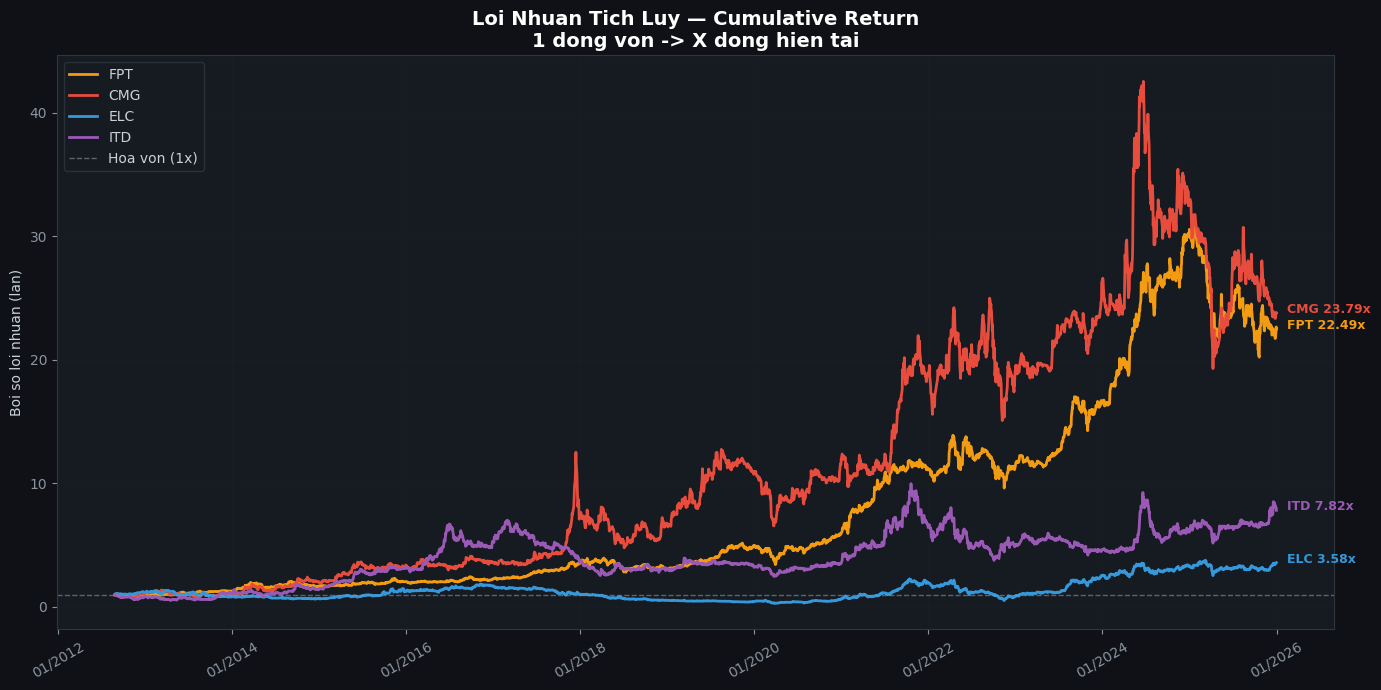

In [4]:
# ── Chart Q1: Cumulative Return ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
for tk, df in stocks.items():
    dc = df.dropna(subset=['cum_return'])
    ax.plot(dc['date'], dc['cum_return'], label=tk, color=COLORS[tk], linewidth=2.0)
    last = dc.iloc[-1]
    ax.annotate(f"{tk} {last['cum_return']:.2f}x", xy=(last['date'], last['cum_return']),
                xytext=(8,0), textcoords='offset points', color=COLORS[tk], fontsize=9, fontweight='bold')
ax.axhline(1.0, color='#8B949E', linestyle='--', linewidth=1.0, alpha=0.6, label='Hoa von (1x)')
ax.set_title('Loi Nhuan Tich Luy — Cumulative Return\n1 dong von -> X dong hien tai', fontsize=14, fontweight='bold')
ax.set_ylabel('Boi so loi nhuan (lan)'); ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y')); plt.xticks(rotation=30)
ax.grid(True, alpha=0.25); plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'q_01_cumulative_return.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

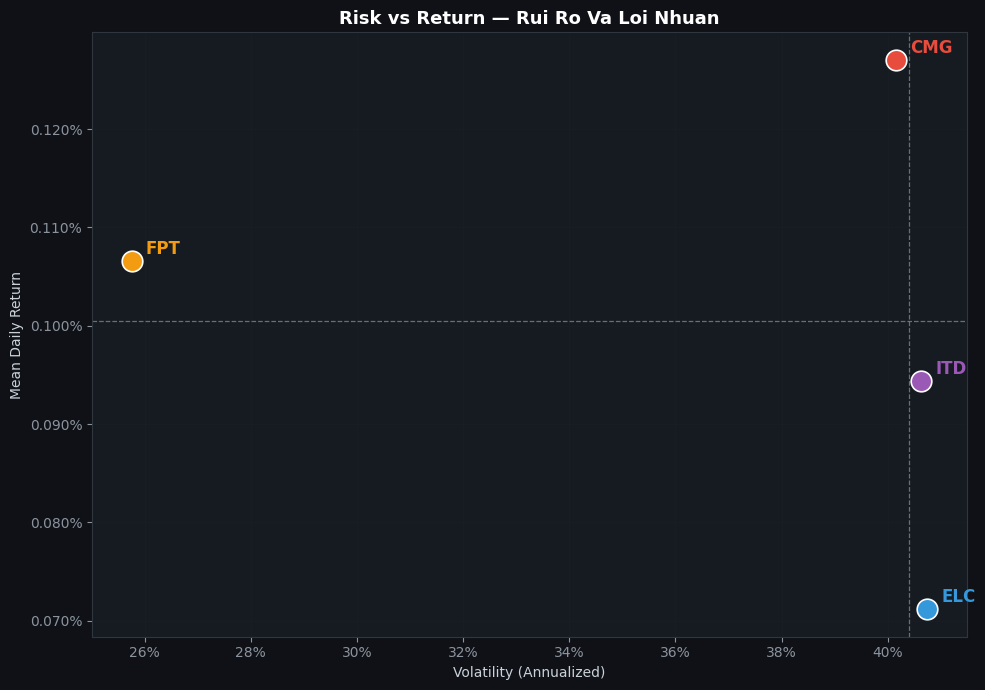

In [5]:
# ── Chart Q2: Risk vs Return ───────────────────────────────────────────────────
summary = [{'ticker': tk, 'volatility': df['daily_return'].std()*np.sqrt(252),
            'mean_return': df['daily_return'].mean()} for tk, df in stocks.items()]
sdf = pd.DataFrame(summary)
med_vol, med_ret = sdf['volatility'].median(), sdf['mean_return'].median()

fig, ax = plt.subplots(figsize=(10, 7))
for _, row in sdf.iterrows():
    ax.scatter(row['volatility'], row['mean_return'], s=220, color=COLORS[row['ticker']], zorder=5, edgecolors='white', linewidths=1.2)
    ax.annotate(row['ticker'], (row['volatility'], row['mean_return']), xytext=(10,5), textcoords='offset points', color=COLORS[row['ticker']], fontsize=12, fontweight='bold')
ax.axhline(med_ret, color='#8B949E', linestyle='--', linewidth=0.9, alpha=0.7)
ax.axvline(med_vol, color='#8B949E', linestyle='--', linewidth=0.9, alpha=0.7)
ax.set_title('Risk vs Return — Rui Ro Va Loi Nhuan', fontsize=13, fontweight='bold')
ax.set_xlabel('Volatility (Annualized)'); ax.set_ylabel('Mean Daily Return')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=3))
ax.grid(True, alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'q_02_risk_return.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## Phân tích Risk-Return 1 năm gần nhất (2024–2025)

In [ ]:
# 1. Tính toán thống kê cho 252 phiên (1 năm gần nhất)
df_risk_return_1y = get_risk_return_stats(stocks, window=252)

print("Thống kê Risk vs Return (1 năm gần nhất - 252 phiên):")
display(df_risk_return_1y.round(2))

Thống kê Risk vs Return (1 năm gần nhất - 252 phiên):


,Annualized Return (%),Annualized Volatility (%),Sharpe Ratio
Ticker,,,
FPT,-24.96,30.79,-0.81
CMG,-26.69,35.64,-0.75
ELC,9.38,30.55,0.31
ITD,29.20,35.29,0.83


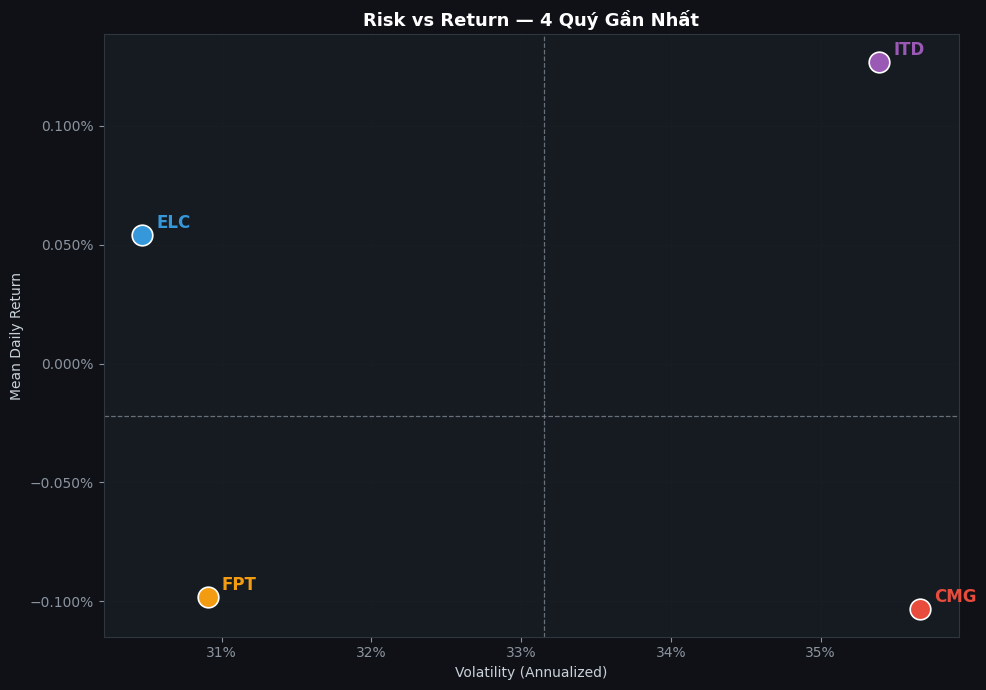

In [6]:
# ── Chart Q2: Risk vs Return — 4 Quý Gần Nhất ──────────────────────────────────

summary_4q = []

for tk, df in stocks.items():
    # Lấy dữ liệu trong 1 năm (4 quý) gần nhất tính từ ngày cuối cùng
    last_date = df['date'].max()
    start_date = last_date - pd.DateOffset(years=1)
    df_4q = df[df['date'] >= start_date]
    
    summary_4q.append({
        'ticker': tk, 
        'volatility': df_4q['daily_return'].std() * np.sqrt(252),
        'mean_return': df_4q['daily_return'].mean()
    })

sdf = pd.DataFrame(summary_4q)
med_vol, med_ret = sdf['volatility'].median(), sdf['mean_return'].median()

fig, ax = plt.subplots(figsize=(10, 7))

for _, row in sdf.iterrows():
    # Vẽ các điểm đại diện cho từng mã
    ax.scatter(row['volatility'], row['mean_return'], s=220, color=COLORS[row['ticker']], 
               zorder=5, edgecolors='white', linewidths=1.2)
    # Ghi nhãn tên mã
    ax.annotate(row['ticker'], (row['volatility'], row['mean_return']), 
                xytext=(10,5), textcoords='offset points', color=COLORS[row['ticker']], 
                fontsize=12, fontweight='bold')

# Vẽ đường trung vị (Median) để phân loại 4 nhóm rủi ro/lợi nhuận
ax.axhline(med_ret, color='#8B949E', linestyle='--', linewidth=0.9, alpha=0.7)
ax.axvline(med_vol, color='#8B949E', linestyle='--', linewidth=0.9, alpha=0.7)

ax.set_title('Risk vs Return — 4 Quý Gần Nhất', fontsize=13, fontweight='bold')
ax.set_xlabel('Volatility (Annualized)')
ax.set_ylabel('Mean Daily Return')

# Định dạng % cho trục tọa độ
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=3))

ax.grid(True, alpha=0.2)
plt.tight_layout()

# Lưu biểu đồ
plt.savefig(os.path.join(IMG_DIR, 'q_02_risk_return_4q.png'), 
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())

plt.show()


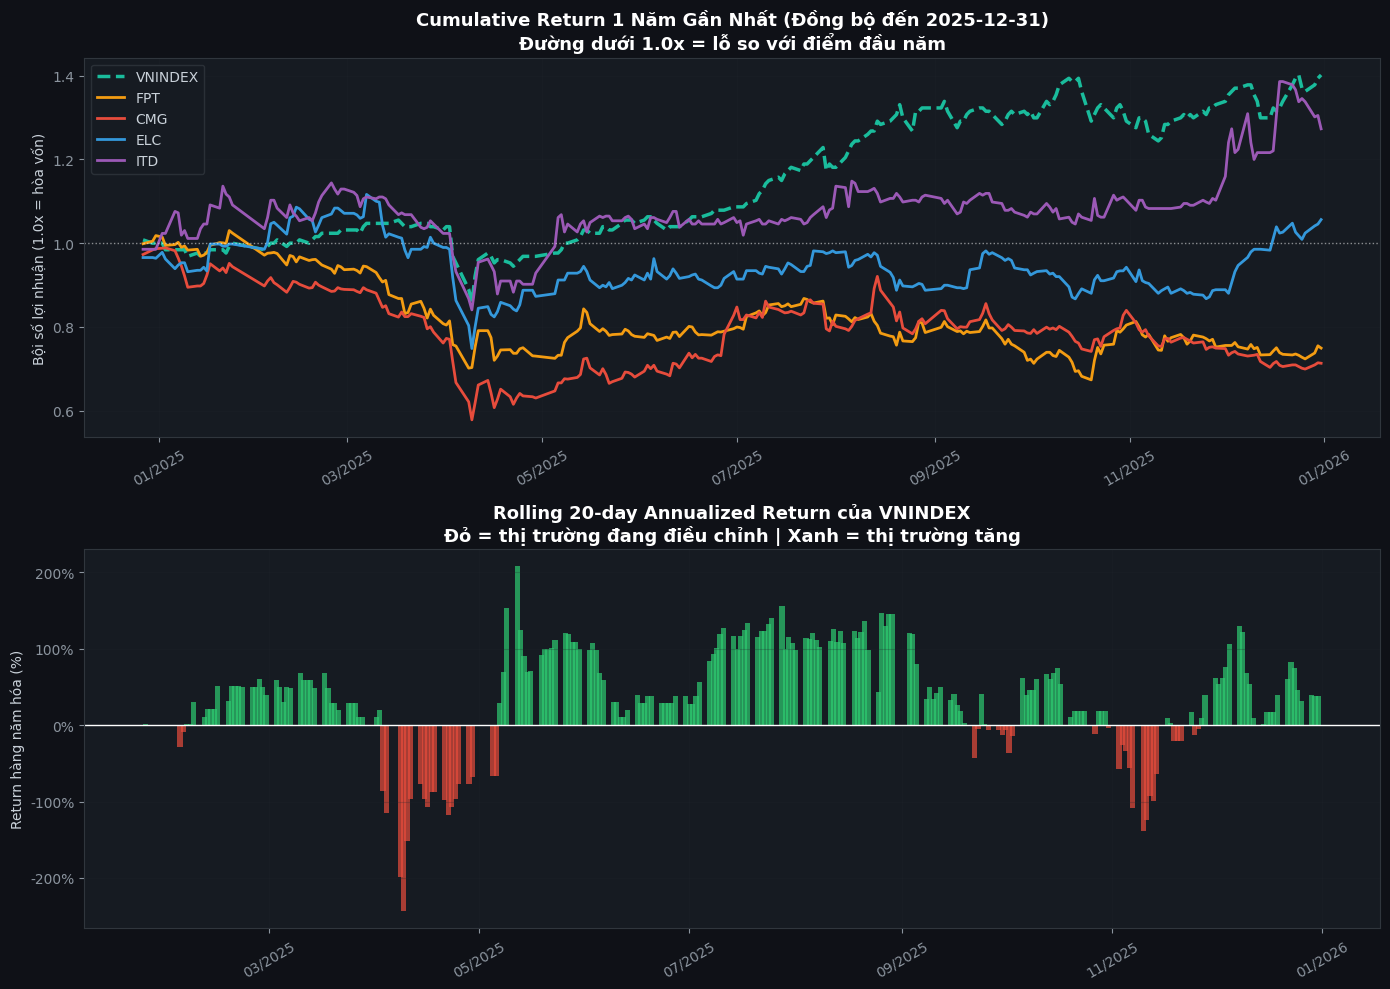


=== Tong ket 1 nam gan nhat (den ngay 2025-12-31) ===
VNINDEX     : +40.2%  (cumulative)
FPT     :  -25.1% (cumulative) | Mean/day=-0.096% | Corr(VNINDEX)=0.56
CMG     :  -28.7% (cumulative) | Mean/day=-0.109% | Corr(VNINDEX)=0.55
ELC     :   +5.6% (cumulative) | Mean/day=+0.040% | Corr(VNINDEX)=0.47
ITD     :  +27.3% (cumulative) | Mean/day=+0.120% | Corr(VNINDEX)=0.34


In [7]:
# ── Chart Q2c: Kiểm tra thị trường điều chỉnh — so sánh FPT/CMG với VNINDEX ──
WINDOW = 252  # 1 năm

# 1. TÌM NGÀY CUỐI CÙNG CHUNG (Dựa trên dữ liệu cổ phiếu để đồng bộ)
last_stock_date = max([df['date'].max() for df in stocks.values()])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Panel 1: Cumulative Return 1 năm của tất cả mã + VNINDEX ──────────────
ax = axes[0]

# VNINDEX 1 năm (Lọc để ngày kết thúc khớp với ngày cuối của cổ phiếu)
vni_1y = df_vni[df_vni['date'] <= last_stock_date].sort_values('date').tail(WINDOW).copy()
vni_1y['cum'] = (1 + vni_1y['daily_return']).cumprod()
ax.plot(vni_1y['date'], vni_1y['cum'],
        label='VNINDEX', color=COLORS['VNINDEX'], linewidth=2.5, linestyle='--')

# Các cổ phiếu 1 năm (Cũng đồng bộ mốc thời gian kết thúc)
for tk, df in stocks.items():
    df_1y = df[df['date'] <= last_stock_date].sort_values('date').tail(WINDOW).copy()
    df_1y['cum'] = (1 + df_1y['daily_return']).cumprod()
    ax.plot(df_1y['date'], df_1y['cum'],
            label=tk, color=COLORS[tk], linewidth=2.0)

ax.axhline(1.0, color='white', linestyle=':', linewidth=1.0, alpha=0.5)
ax.set_title(f'Cumulative Return 1 Năm Gần Nhất (Đồng bộ đến {last_stock_date.date()})\n'
             'Đường dưới 1.0x = lỗ so với điểm đầu năm', fontsize=13, fontweight='bold')
ax.set_ylabel('Bội số lợi nhuận (1.0x = hòa vốn)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.setp(ax.get_xticklabels(), rotation=30)

# ── Panel 2: Rolling 20-day return của VNINDEX (hiển thị xu hướng thị trường) ──
ax2 = axes[1]

vni_1y['rolling_ret'] = vni_1y['daily_return'].rolling(20).mean() * 252 * 100
ax2.bar(vni_1y['date'], vni_1y['rolling_ret'],
        color=['#E74C3C' if v < 0 else '#2ECC71' for v in vni_1y['rolling_ret']],
        alpha=0.7, width=1.5)
ax2.axhline(0, color='white', linewidth=1.0)
ax2.set_title('Rolling 20-day Annualized Return của VNINDEX\n'
              'Đỏ = thị trường đang điều chỉnh | Xanh = thị trường tăng', fontsize=13, fontweight='bold')
ax2.set_ylabel('Return hàng năm hóa (%)')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.grid(True, alpha=0.25)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.setp(ax2.get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'q_02c_market_correction_check.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

# ── Tóm tắt số liệu (Dựa trên ngày đã đồng bộ) ──────────────────────────────
print(f'\n=== Tong ket 1 nam gan nhat (den ngay {last_stock_date.date()}) ===')
vni_total = vni_1y['cum'].iloc[-1] - 1
print(f'VNINDEX     : {vni_total*100:+.1f}%  (cumulative)')
for tk, df in stocks.items():
    df_1y = df[df['date'] <= last_stock_date].sort_values('date').tail(WINDOW).copy()
    cum_ret = (1 + df_1y['daily_return']).cumprod().iloc[-1] - 1
    mean_d  = df_1y['daily_return'].mean() * 100
    
    # Tính tương quan dựa trên chuỗi đã khớp ngày
    vni_aligned = vni_1y.set_index('date')['daily_return']
    stock_aligned = df_1y.set_index('date')['daily_return']
    corr_vni = stock_aligned.corr(vni_aligned)
    
    print(f'{tk:8s}: {cum_ret*100:+6.1f}% (cumulative) | Mean/day={mean_d:+.3f}% | Corr(VNINDEX)={corr_vni:.2f}')


Correlation with VNINDEX:
  FPT: Pearson=+0.628, Spearman=+0.530
  CMG: Pearson=+0.411, Spearman=+0.355
  ELC: Pearson=+0.388, Spearman=+0.303
  ITD: Pearson=+0.313, Spearman=+0.221


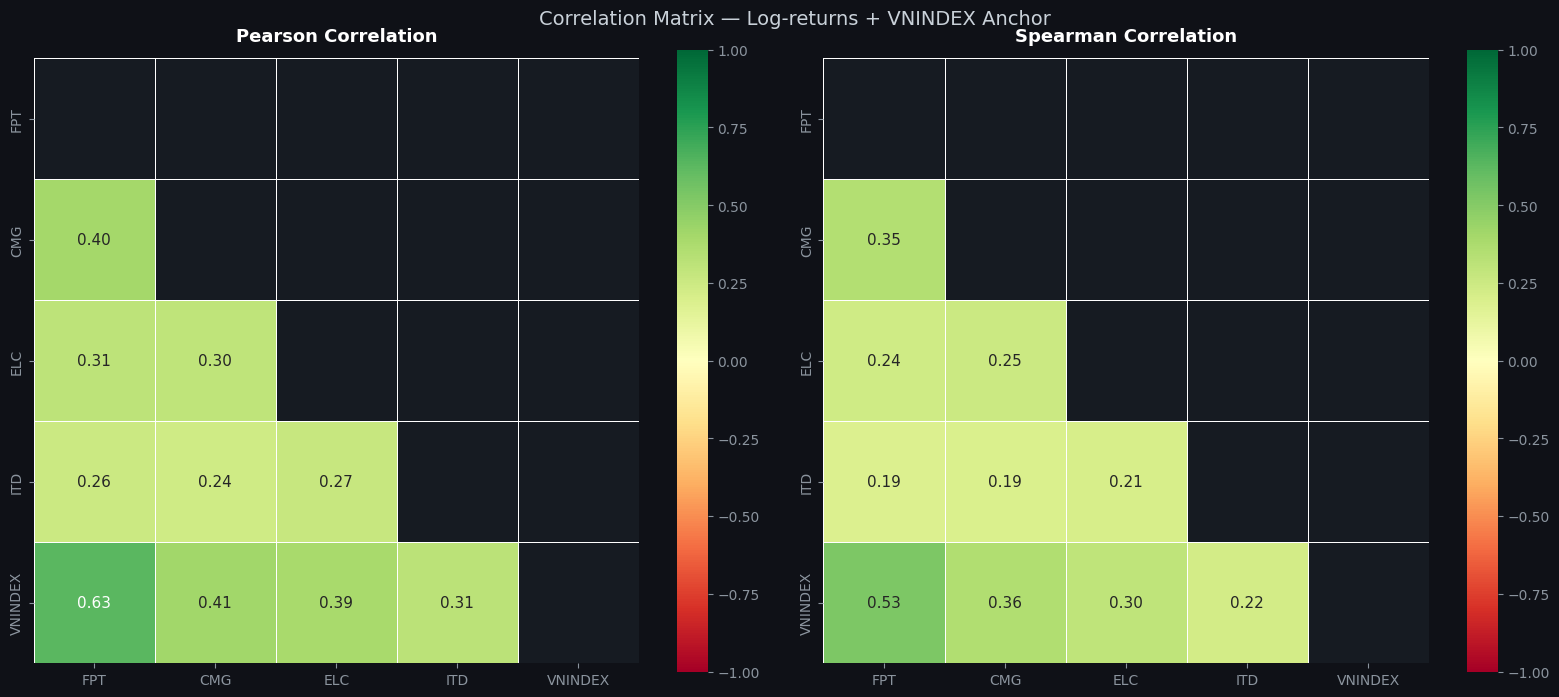

In [8]:
# ── Chart Q3: Correlation Heatmaps (Pearson + Spearman) ───────────────────────
ret_df = pd.concat([df.set_index('date')['daily_return'].rename(tk) for tk, df in stocks.items()], axis=1).dropna()

# Add VNINDEX returns
vni_ret = df_vni.set_index('date')['daily_return'].rename('VNINDEX')
ret_all = ret_df.join(vni_ret, how='inner').dropna()

pearson  = ret_all.corr(method='pearson')
spearman = ret_all.corr(method='spearman')

print('Correlation with VNINDEX:')
for tk in TICKERS:
    print(f'  {tk}: Pearson={pearson.loc[tk,"VNINDEX"]:+.3f}, Spearman={spearman.loc[tk,"VNINDEX"]:+.3f}')

mask = np.triu(np.ones_like(pearson, dtype=bool))
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, corr, title in zip(axes, [pearson, spearman], ['Pearson', 'Spearman']):
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
                square=True, linewidths=0.5, ax=ax, annot_kws={'size': 11})
    ax.set_title(f'{title} Correlation', fontsize=13, fontweight='bold', pad=12)
plt.suptitle('Correlation Matrix — Log-returns + VNINDEX Anchor', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'q_03_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

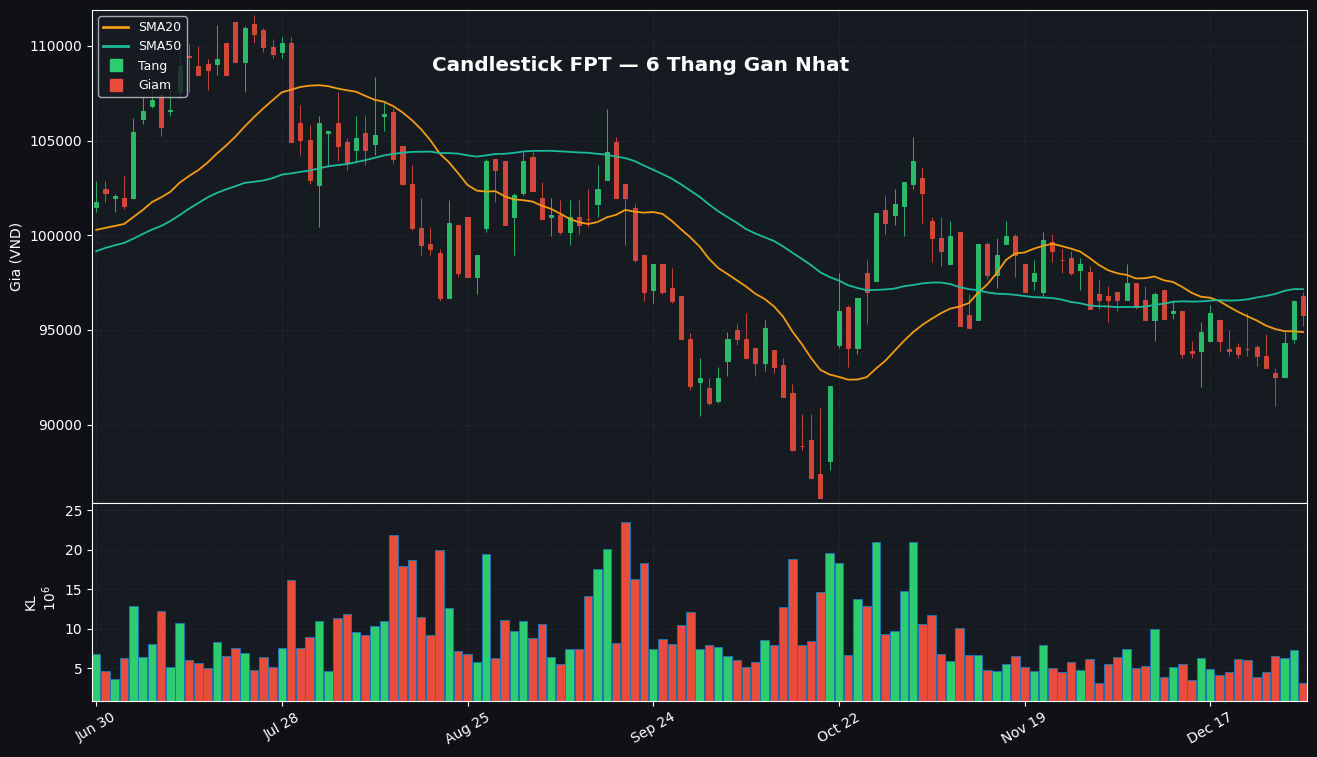

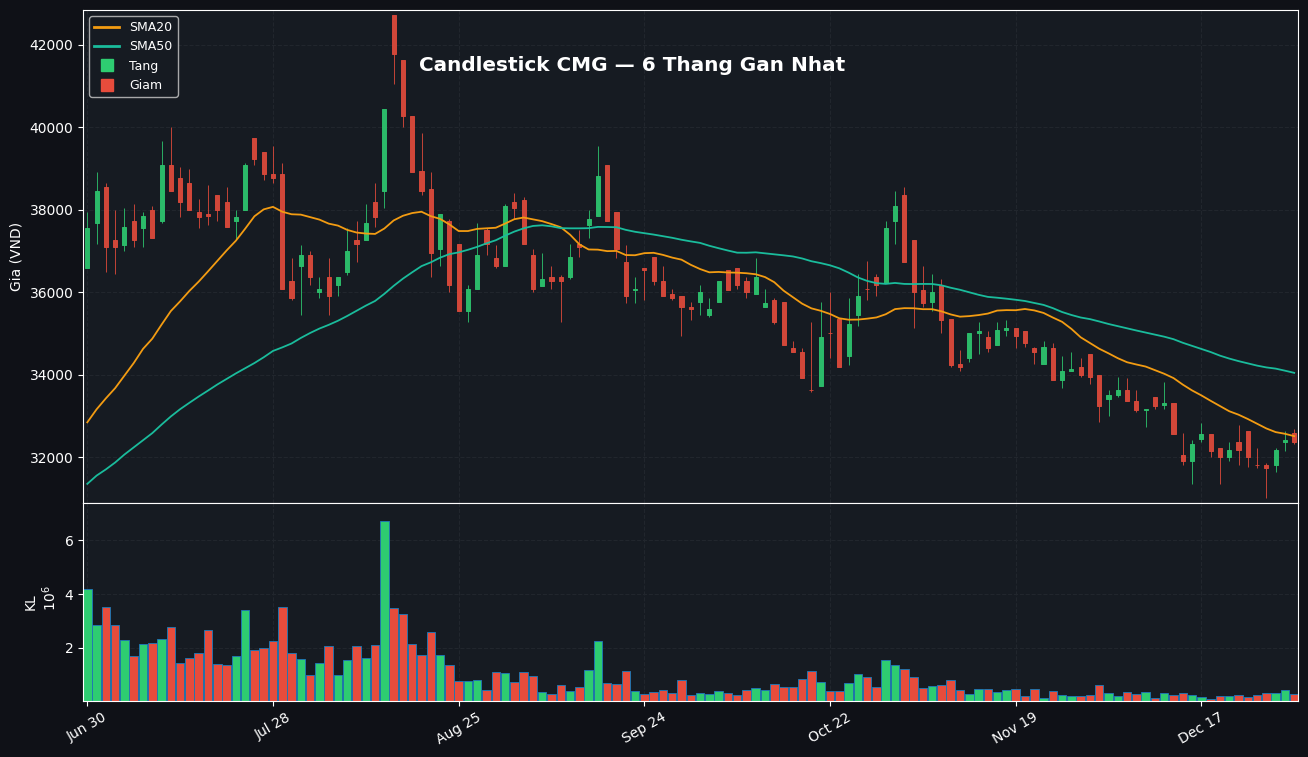

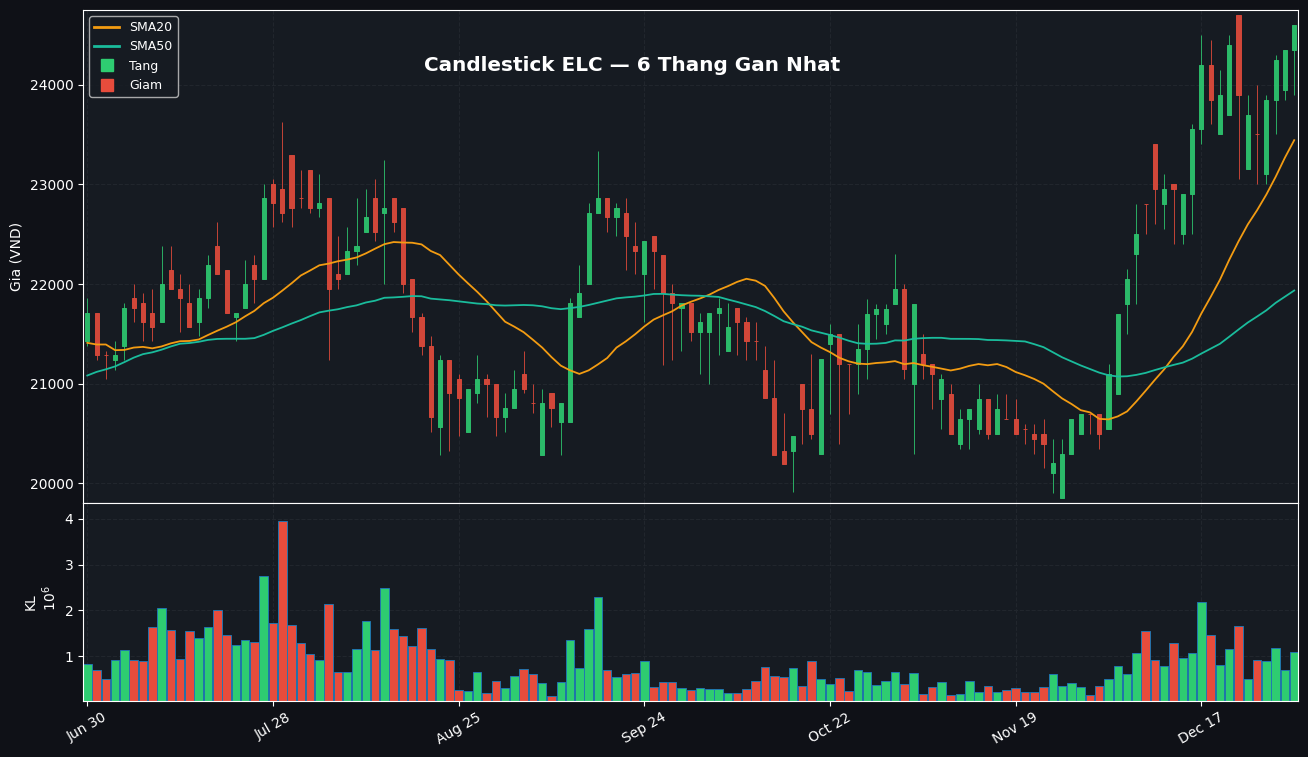

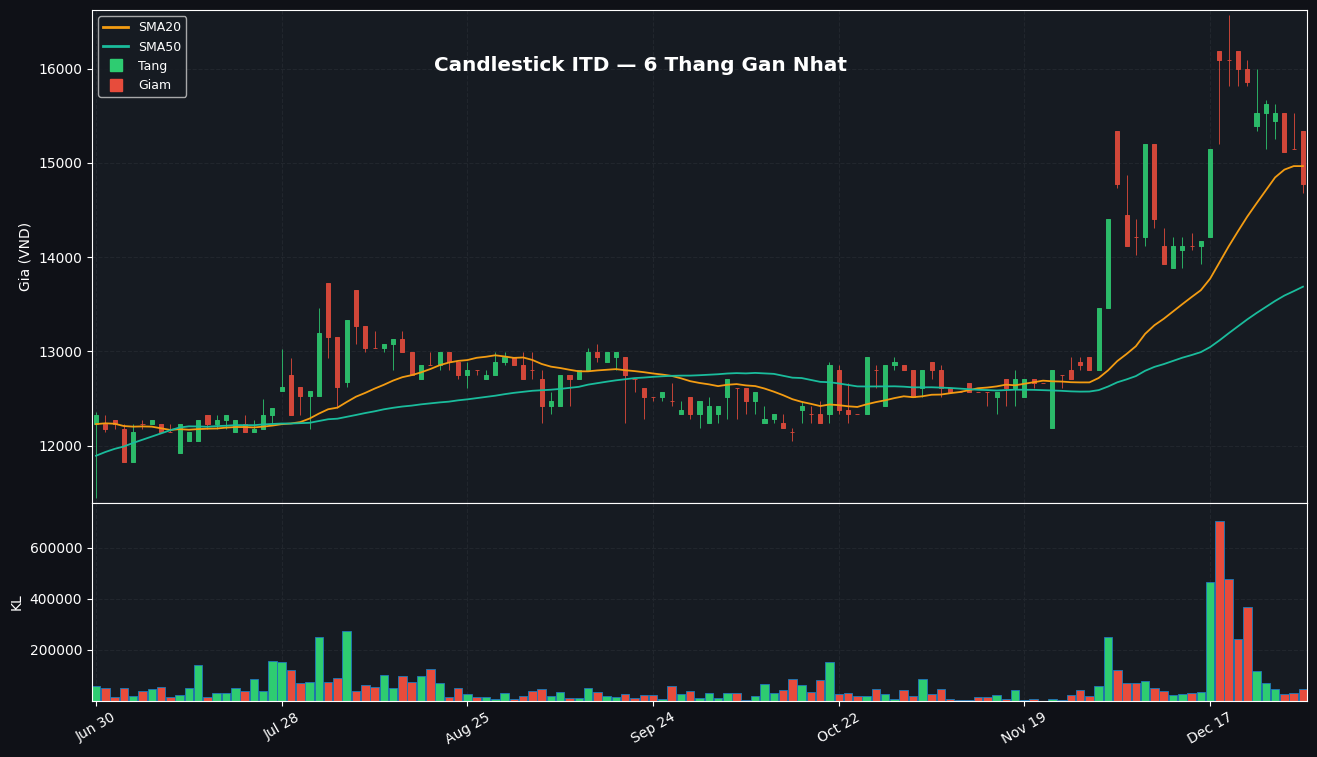

In [9]:
# ── Chart Q4: Candlestick (tất cả 4 mã, 6 tháng gần nhất) ────────────────────
mc    = mpf.make_marketcolors(up='#2ECC71', down='#E74C3C', edge='inherit', wick='inherit', volume={'up':'#2ECC71','down':'#E74C3C'})
style = mpf.make_mpf_style(base_mpf_style='nightclouds', marketcolors=mc, facecolor='#161B22', figcolor='#0F1117', gridcolor='#21262D', gridstyle='--')

for tk, df in stocks.items():
    cutoff = df['date'].max() - pd.DateOffset(months=6)
    df6 = df[df['date'] >= cutoff].copy()
    df_mpf = df6.set_index('date')[['open','high','low','close','volume']].copy()
    df_mpf.columns = ['Open','High','Low','Close','Volume']
    df_mpf.index.name = 'Date'

    adds = [
        mpf.make_addplot(df6.set_index('date')['sma_20'].values, panel=0, color='#F39C12', linewidths=1.5, label='SMA20'),
        mpf.make_addplot(df6.set_index('date')['sma_50'].values, panel=0, color='#1ABC9C', linewidths=1.5, label='SMA50'),
    ]
    fig, axes = mpf.plot(df_mpf, type='candle', style=style, volume=True, addplot=adds,
                         figsize=(14, 8), title=f'\nCandlestick {tk} — 6 Thang Gan Nhat',
                         ylabel='Gia (VND)', ylabel_lower='KL', returnfig=True, tight_layout=True, xrotation=30)
    legend_el = [Line2D([0],[0],color='#F39C12',lw=2,label='SMA20'), Line2D([0],[0],color='#1ABC9C',lw=2,label='SMA50'),
                 Line2D([0],[0],color='#2ECC71',lw=0,marker='s',markersize=9,label='Tang'),
                 Line2D([0],[0],color='#E74C3C',lw=0,marker='s',markersize=9,label='Giam')]
    axes[0].legend(handles=legend_el, loc='upper left', fontsize=9, framealpha=0.8)
    fig.savefig(os.path.join(IMG_DIR, f'q_04_candle_{tk.lower()}.png'), dpi=150, bbox_inches='tight', facecolor='#0F1117')
    plt.show()
    plt.close(fig)

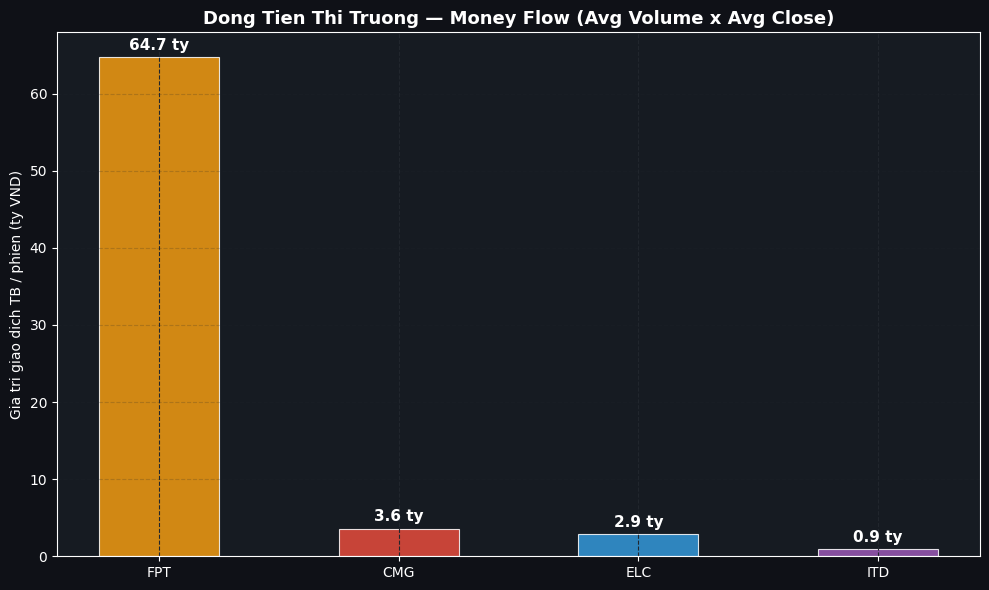

In [10]:
# ── Chart Q5: Money Flow ───────────────────────────────────────────────────────
flow = {tk: df['volume'].mean() * df['close'].mean() / 1e9 for tk, df in stocks.items()}
flow_df = pd.Series(flow).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(flow_df.index, flow_df.values, color=[COLORS[t] for t in flow_df.index], alpha=0.85, edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, flow_df.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + flow_df.max()*0.015, f'{val:.1f} ty', ha='center', fontsize=11, fontweight='bold', color='white')
ax.set_title('Dong Tien Thi Truong — Money Flow (Avg Volume x Avg Close)', fontsize=13, fontweight='bold')
ax.set_ylabel('Gia tri giao dich TB / phien (ty VND)'); ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'q_05_money_flow.png'), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

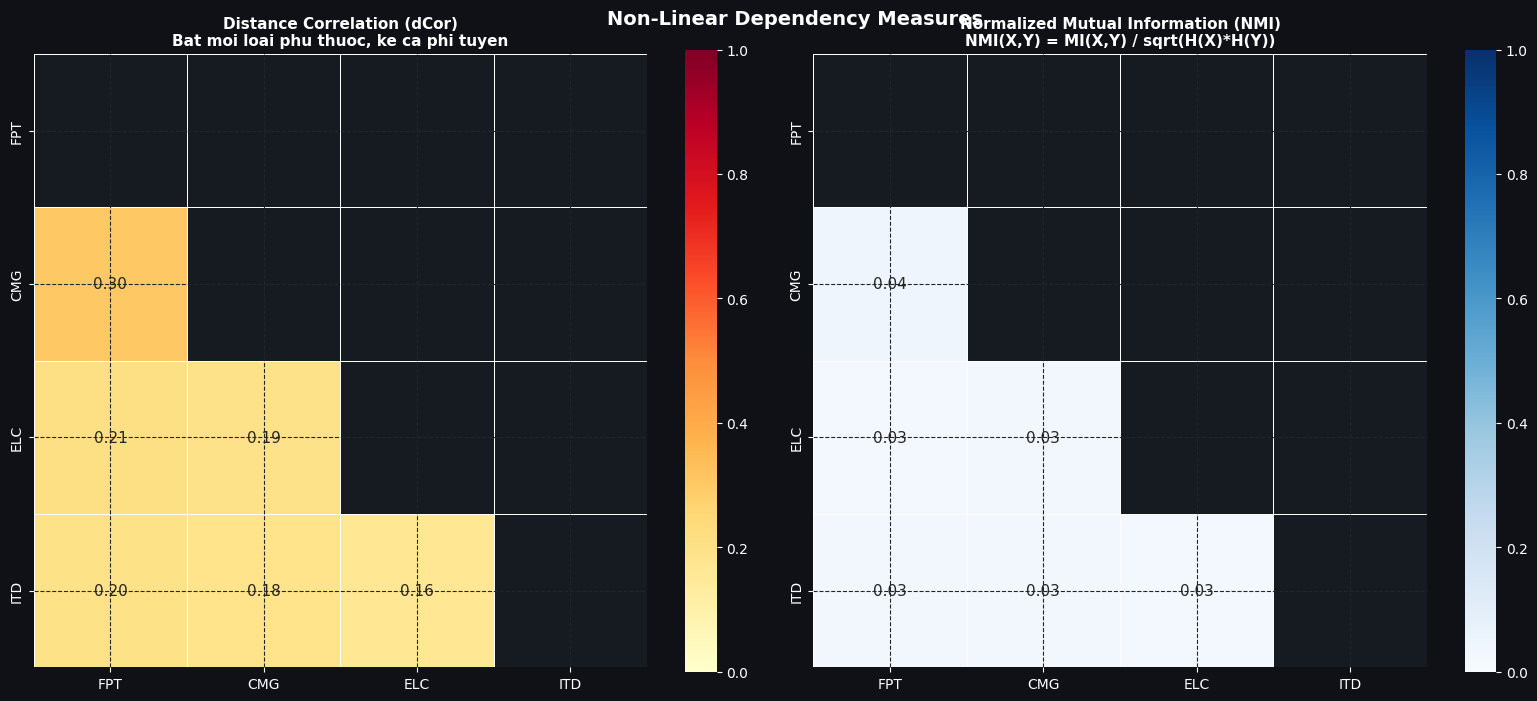

In [11]:
# ── Chart Q6: Non-Linear Correlation (NMI + Distance Correlation) ─────────────
data_np = ret_df.dropna().values
cols    = list(ret_df.columns)
n       = len(cols)

# Distance Correlation
def dist_corr(X, Y):
    X = np.array(X).reshape(-1,1); Y = np.array(Y).reshape(-1,1)
    def cd(Z):
        d = np.sqrt(np.sum((Z[:,None]-Z[None,:])**2, axis=-1))
        return d - d.mean(1,keepdims=True) - d.mean(0,keepdims=True) + d.mean()
    A, B = cd(X), cd(Y)
    cxy = np.sqrt(max((A*B).mean(), 0))
    denom = np.sqrt(np.sqrt(max((A*A).mean(),0)) * np.sqrt(max((B*B).mean(),0)))
    return float(cxy / denom) if denom > 0 else 0.0

dcor_m = np.eye(n)
for i in range(n):
    for j in range(i+1, n):
        v = dist_corr(data_np[:,i], data_np[:,j])
        dcor_m[i,j] = dcor_m[j,i] = v
dcor_df = pd.DataFrame(dcor_m, index=cols, columns=cols)

# Normalized Mutual Information
kbd = KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='quantile')
disc = kbd.fit_transform(data_np)
nmi_m = np.eye(n)
for i in range(n):
    for j in range(i+1, n):
        mi = mutual_info_score(disc[:,i], disc[:,j])
        hi = mutual_info_score(disc[:,i], disc[:,i])
        hj = mutual_info_score(disc[:,j], disc[:,j])
        denom = np.sqrt(hi * hj)
        v = float(mi / denom) if denom > 0 else 0.0
        nmi_m[i,j] = nmi_m[j,i] = v
nmi_df = pd.DataFrame(nmi_m, index=cols, columns=cols)

mask = np.triu(np.ones((n,n), dtype=bool))
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(dcor_df, mask=mask, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, square=True, linewidths=0.5, ax=axes[0], annot_kws={'size':11})
axes[0].set_title('Distance Correlation (dCor)\nBat moi loai phu thuoc, ke ca phi tuyen', fontsize=11, fontweight='bold')
sns.heatmap(nmi_df, mask=mask, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, square=True, linewidths=0.5, ax=axes[1], annot_kws={'size':11})
axes[1].set_title('Normalized Mutual Information (NMI)\nNMI(X,Y) = MI(X,Y) / sqrt(H(X)*H(Y))', fontsize=11, fontweight='bold')
plt.suptitle('Non-Linear Dependency Measures', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'q_06_nonlinear_corr.png'), dpi=150, bbox_inches='tight')
plt.show()

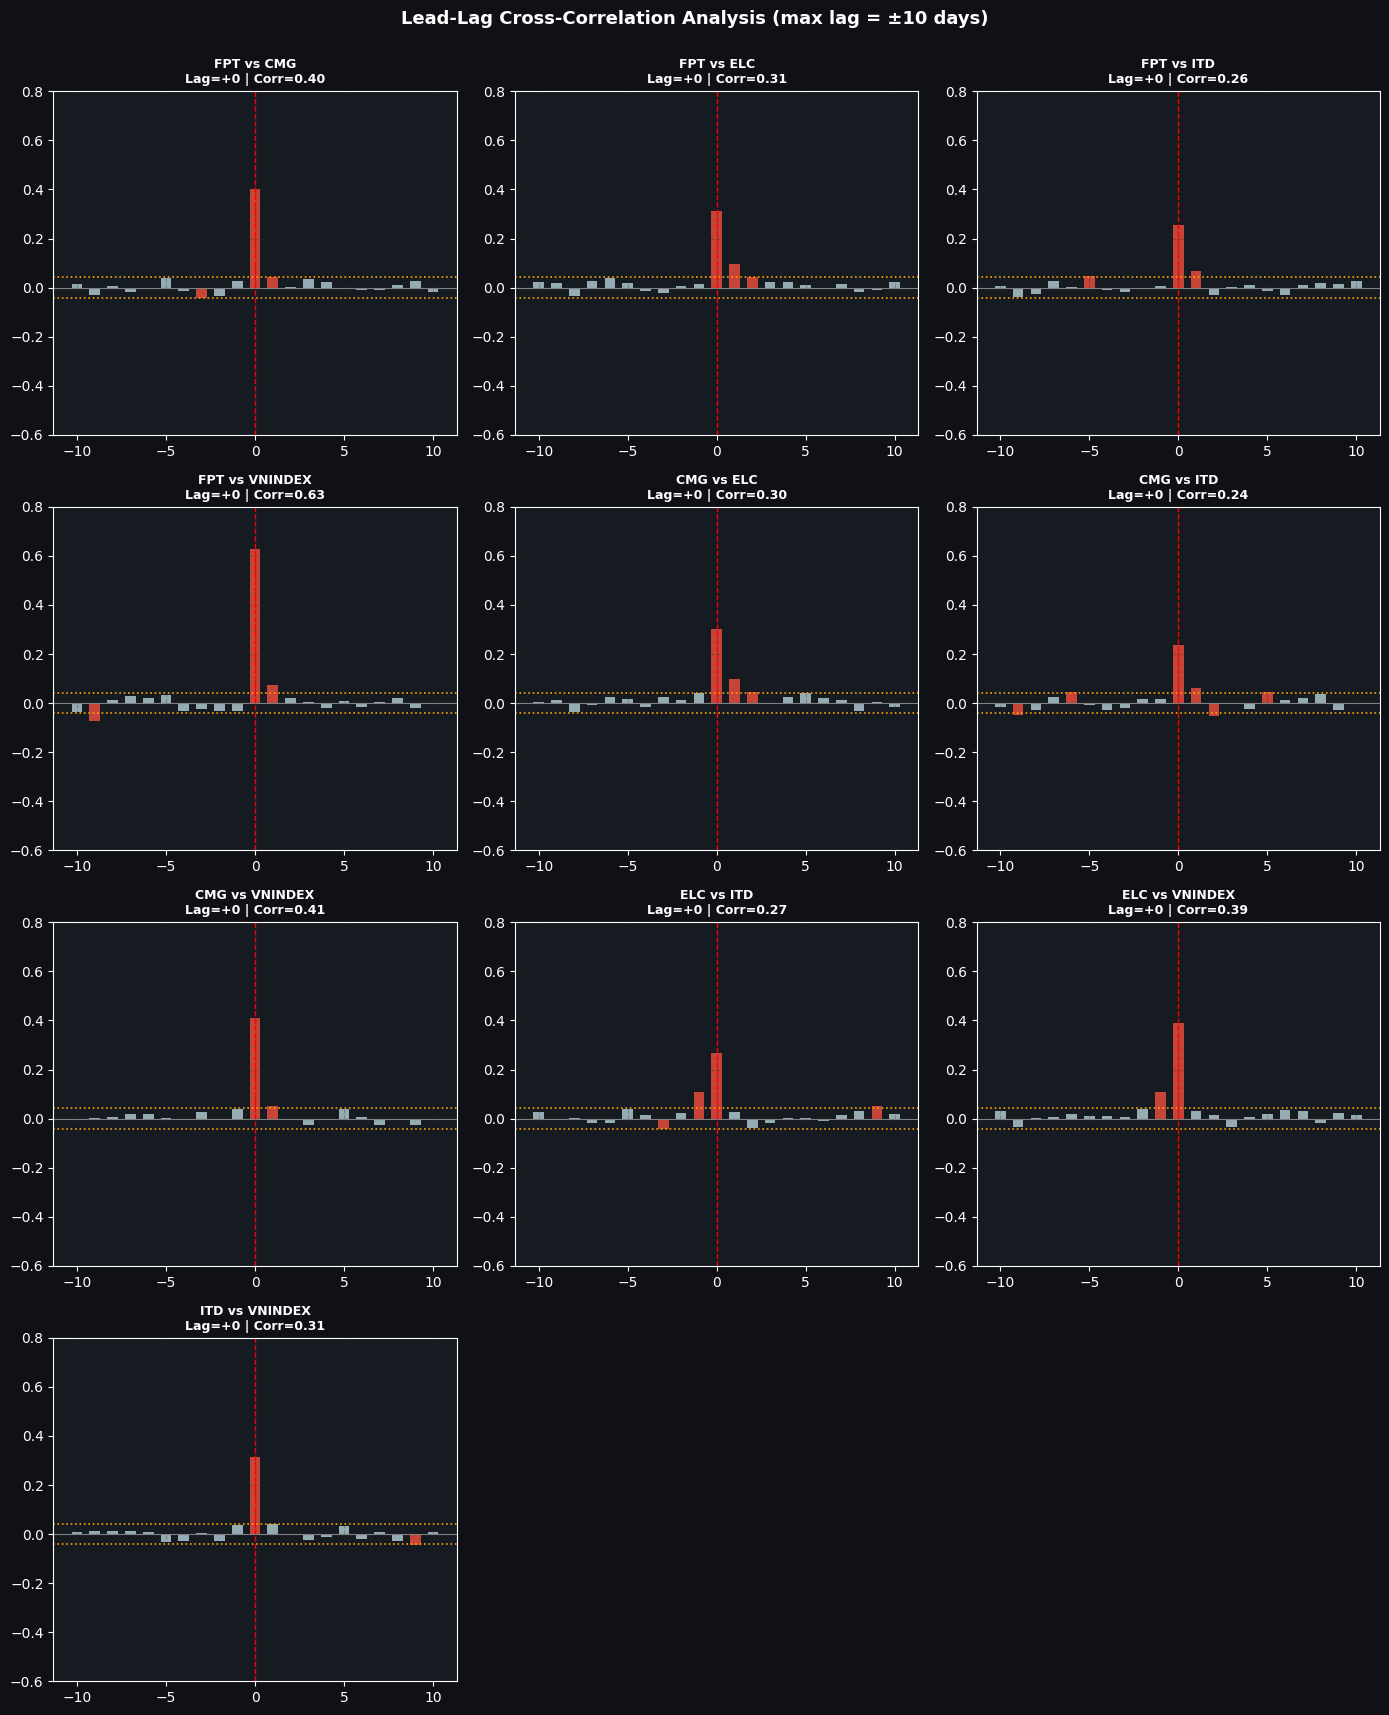


                            BẢNG TỔNG HỢP CHỈ SỐ LEAD-LAG                            


,Cặp so sánh,Lag tối ưu,Tương quan Max,Kết luận,Độ trễ
0,FPT vs CMG,0,0.4012,Đồng biến (Synchronized),0 ngày
1,FPT vs ELC,0,0.3112,Đồng biến (Synchronized),0 ngày
2,FPT vs ITD,0,0.2557,Đồng biến (Synchronized),0 ngày
3,FPT vs VNINDEX,0,0.6279,Đồng biến (Synchronized),0 ngày
4,CMG vs ELC,0,0.3000,Đồng biến (Synchronized),0 ngày
5,CMG vs ITD,0,0.2366,Đồng biến (Synchronized),0 ngày
6,CMG vs VNINDEX,0,0.4107,Đồng biến (Synchronized),0 ngày
7,ELC vs ITD,0,0.2692,Đồng biến (Synchronized),0 ngày
8,ELC vs VNINDEX,0,0.3882,Đồng biến (Synchronized),0 ngày
9,ITD vs VNINDEX,0,0.3127,Đồng biến (Synchronized),0 ngày


In [12]:
# ── Chart Q7: Lead-Lag Analysis & Summary Table ───────────────────────────────

all_cols = list(ret_df.columns) + ['VNINDEX']
ret_full = ret_df.join(vni_ret, how='inner').dropna()
pairs    = [(all_cols[i], all_cols[j]) for i in range(len(all_cols)) for j in range(i+1, len(all_cols))]
lags     = list(range(-10, 11))
ci       = 1.96 / np.sqrt(len(ret_full))

# List để lưu các chỉ số in ra
lead_lag_results = []

ncols = 3
nrows = (len(pairs) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = axes.flatten()

for i, (a, b) in enumerate(pairs):
    ccf_vals = [ret_full[a].corr(ret_full[b].shift(-lag)) for lag in lags]
    max_idx  = int(np.argmax(np.abs(ccf_vals)))
    opt_lag  = lags[max_idx]
    max_corr = ccf_vals[max_idx]
    
    # Xác định kết luận
    if opt_lag < 0:
        conclusion = f'{a} dẫn dắt (leads) {b}'
        detail = f'{abs(opt_lag)} ngày'
    elif opt_lag > 0:
        conclusion = f'{b} dẫn dắt (leads) {a}'
        detail = f'{opt_lag} ngày'
    else:
        conclusion = 'Đồng biến (Synchronized)'
        detail = '0 ngày'
        
    # Lưu vào danh sách kết quả
    lead_lag_results.append({
        'Cặp so sánh': f'{a} vs {b}',
        'Lag tối ưu': opt_lag,
        'Tương quan Max': round(max_corr, 4),
        'Kết luận': conclusion,
        'Độ trễ': detail
    })

    # Vẽ biểu đồ
    bar_colors = ['#E74C3C' if abs(v) > ci else '#AEC6CF' for v in ccf_vals]
    axes[i].bar(lags, ccf_vals, color=bar_colors, alpha=0.85, width=0.6)
    axes[i].axhline(0, color='gray', linewidth=0.8)
    axes[i].axhline(ci,  color='orange', linestyle=':', linewidth=1.2)
    axes[i].axhline(-ci, color='orange', linestyle=':', linewidth=1.2)
    axes[i].axvline(0,   color='red', linestyle='--', linewidth=1.0)
    axes[i].set_title(f'{a} vs {b}\nLag={opt_lag:+d} | Corr={max_corr:.2f}', fontsize=9, fontweight='bold')
    axes[i].set_ylim(-0.6, 0.8)
    axes[i].grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].axis('off')
plt.suptitle('Lead-Lag Cross-Correlation Analysis (max lag = ±10 days)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig(os.path.join(IMG_DIR, 'q_07_lead_lag.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- PHẦN IN CHỈ SỐ (SUMMARY TABLE) ---
print("\n" + "="*85)
print(f"{'BẢNG TỔNG HỢP CHỈ SỐ LEAD-LAG':^85}")
print("="*85)
summary_df = pd.DataFrame(lead_lag_results)
# Định dạng in bảng đẹp hơn bằng pandas
from IPython.display import display
display(summary_df)
print("="*85)
